---
title: "Kronecker-multiplicative GP — spatially varying warming rates"
---

# Annual temperature extremes over Spain — part 2: a spatially varying climate response

A direct follow-up to [01_spain_extremes](01_spain_extremes.ipynb). Same
block-maxima data, same `xtremax` GEV likelihood, same Iberian grid — but we
**upgrade $\beta$ from a scalar to a spatial GP**, so each location gets its
own warming amplification rate.

Notebook 01 fit an *additive* field $\tau(s,t) = \mu(s) + \beta\,d(t) + \tau_r(t)$
with a **single scalar $\beta$**. Here we replace $\beta$ with a spatial GP
$\beta(s)$, giving a *multiplicative* (rank-1 space–time) interaction

$$\tau(s, t) = \mu_0 + \mu(s) + \beta(s)\,\bigl(\mathrm{GMST}(t) - \overline{\mathrm{GMST}}\bigr),$$

and drops the temporal residual. As in nb 01 the model is a NumPyro program:
latent spatial fields via `pyrox.gp` whitened `gp_sample`, an `xtremax` GEV
likelihood, and SVI with an `AutoNormal` guide.

## Background — the multiplicative model

### From scalar to field

- $\mu(s) \sim \mathcal{GP}(0, k_\mu)$ — the **constant spatial residual**
  (the time-invariant climate offset of each location).
- $\beta(s) = \beta_0 + \tilde{\beta}(s),\ \tilde{\beta} \sim \mathcal{GP}(0, k_\beta)$
  — the **spatially varying warming rate**. Prior mean $\beta_0 \approx 1$ =
  "one degree of global warming raises local extremes by one degree".

The latent field on the $S \times T$ grid is
$\tau(s_i, t_j) = \mu_0 + \mu(s_i) + \beta(s_i)\,d_j$ with
$d_j = \mathrm{GMST}(t_j) - \overline{\mathrm{GMST}}$, and observations are
$y(s_i, t_j) \sim \mathrm{GEV}(\tau(s_i,t_j), \sigma, \xi)$.

### Covariance on the full grid — a sum of two Kronecker products

Since $\mu$ and $\tilde{\beta}$ are a priori independent GPs,

$$K_\tau \;=\; K_\mu \otimes J_T \;+\; K_\beta \otimes d d^\top, \qquad J_T = \mathbf{1}_T \mathbf{1}_T^\top,$$

a **sum of two Kronecker products** (`gaussx.SumKronecker`). Both right-hand
factors are rank-1, so the prior's time-rank is 2 — the hallmark of the
multiplicative model. We display this operator below for intuition, though the
inference works directly with the two spatial GPs.

### Identifiability

Two traps, both handled by **centering the latent fields** (so $\mu_0$ owns the
global level and $\beta_0$ owns the mean warming rate):

1. $\mu(s)$ vs $\beta(s)$ at $d = 0$ — centering $d$ around its mean spreads
   $\beta$ information over the whole record.
2. $\beta_0$ vs the mean of $\tilde{\beta}$ — centering $\tilde\beta$ to be
   zero-mean pins the mean rate on $\beta_0$.

## Setup

In [1]:
import time

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import lineax as lx
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Predictive, Trace_ELBO, autoguide
from numpyro.infer.initialization import init_to_value
from jaxtyping import Array, Float
from scipy.stats import genextreme

import gaussx
from pyrox.gp import GPPrior, Matern, gp_sample
from pyrox.gp._src.kernels import matern_kernel
from xtremax import GeneralizedExtremeValueDistribution as GEV
from xtremax import gev_return_level

jax.config.update("jax_enable_x64", True)

/home/user/research_notebook/projects/gaussian_processes/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Synthetic data — a warming Spain with heterogeneous response

Stations and GMST are identical to nb 01 so the two can be compared directly.

In [2]:
SPAIN_BBOX = (-9.5, 3.5, 36.0, 43.8)


def _on_land(lon: Float[Array, " N"], lat: Float[Array, " N"]) -> Float[Array, " N"]:
    west_of_galicia = (lon < -8.8) & (lat > 42.3)
    below_africa = lat < 36.2
    east_mediterranean = (lon > 2.5) & (lat < 39.0)
    return ~(west_of_galicia | below_africa | east_mediterranean)


def _sample_stations(key: jr.PRNGKey, n_target: int) -> Float[Array, "n 2"]:
    candidates = jr.uniform(
        key, (n_target * 4, 2),
        minval=jnp.array([SPAIN_BBOX[0], SPAIN_BBOX[2]]),
        maxval=jnp.array([SPAIN_BBOX[1], SPAIN_BBOX[3]]),
    )
    return candidates[_on_land(candidates[:, 0], candidates[:, 1])][:n_target]


S = 40
T = 40
YEAR_0 = 1985
YEARS = jnp.arange(YEAR_0, YEAR_0 + T)

key = jr.PRNGKey(2024)
key, key_stations = jr.split(key)
stations = _sample_stations(key_stations, S)
lon_st = stations[:, 0]
lat_st = stations[:, 1]

### GMST proxy — linear trend + AR(1) red noise (same as nb 01)

In [3]:
def synthetic_gmst(years: Float[Array, " T"], key: jr.PRNGKey) -> Float[Array, " T"]:
    t_norm = (years - years[0]) / jnp.maximum(years[-1] - years[0], 1)
    trend = 0.1 + 0.8 * t_norm
    white = 0.05 * jr.normal(key, (years.shape[0],))

    def step(prev, eps):
        cur = 0.6 * prev + eps
        return cur, cur

    _, red = jax.lax.scan(step, white[0], white[1:])
    return trend + jnp.concatenate([white[:1], red])


key, key_gmst = jr.split(key)
gmst = synthetic_gmst(YEARS, key_gmst)
d_vec = gmst - jnp.mean(gmst)  # centred GMST anomaly
print(f"GMST range:  {float(gmst[0]):.2f}  ->  {float(gmst[-1]):.2f} °C")
print(f"d range:     {float(d_vec.min()):+.2f}  ->  {float(d_vec.max()):+.2f} °C (centred)")

GMST range:  0.02  ->  0.85 °C
d range:     -0.46  ->  +0.37 °C (centred)


### Ground-truth $\beta^*(s)$ drawn from a Matern GP

$\beta^*(s)$ is drawn from a spatial GP with a known kernel so the GP prior is
well-specified. Prior mean $\beta_0^* = 1.2$; fluctuations from a zero-mean
Matern-3/2 kernel (variance $0.25$, lengthscale $3°$). Covariances are built
with `pyrox`'s pure `matern_kernel`.

In [4]:
def draw_from_gp(K: Float[Array, "N N"], key: jr.PRNGKey, jitter: float = 1e-4) -> Float[Array, " N"]:
    L = jnp.linalg.cholesky(K + jitter * jnp.eye(K.shape[0]))
    return L @ jr.normal(key, (K.shape[0],))


TRUTH = {
    "mu0": 35.0, "k_s_var": 4.0, "k_s_ls": 2.0,
    "k_beta_var": 0.25, "k_beta_ls": 3.0, "beta0": 1.2,
    "gev_sigma": 1.8, "gev_xi": 0.12,
}

K_s_truth = matern_kernel(stations, stations, jnp.asarray(TRUTH["k_s_var"]), jnp.asarray(TRUTH["k_s_ls"]), nu=1.5)
K_beta_truth = matern_kernel(stations, stations, jnp.asarray(TRUTH["k_beta_var"]), jnp.asarray(TRUTH["k_beta_ls"]), nu=1.5)

key, key_mu, key_beta = jr.split(key, 3)
mu_truth = draw_from_gp(K_s_truth, key_mu)
beta_truth = TRUTH["beta0"] + draw_from_gp(K_beta_truth, key_beta)
print(f"beta*(s) range:  {float(beta_truth.min()):.2f}  ->  {float(beta_truth.max()):.2f}  "
      f"(mean {float(beta_truth.mean()):.2f}, truth beta0 {TRUTH['beta0']:.2f})")

f_truth = TRUTH["mu0"] + mu_truth[:, None] + beta_truth[:, None] * d_vec[None, :]  # (S, T)

beta*(s) range:  -0.02  ->  2.85  (mean 1.23, truth beta0 1.20)


### GEV observation model — from `xtremax`, verified vs scipy

In [5]:
y_grid = jnp.linspace(-2.0, 25.0, 60)
ours = GEV(loc=3.0, scale=1.5, concentration=0.2).log_prob(y_grid)
theirs = genextreme.logpdf(np.asarray(y_grid), c=-0.2, loc=3.0, scale=1.5)
print(f"xtremax GEV vs scipy (ξ=0.2)  max|Δ| = {float(jnp.max(jnp.abs(ours - theirs))):.2e}")

key, key_obs = jr.split(key)
y_obs = GEV(loc=f_truth, scale=TRUTH["gev_sigma"], concentration=TRUTH["gev_xi"]).sample(key_obs)
Y_MEAN = float(jnp.mean(y_obs))
print(f"y_obs shape: {y_obs.shape}  range: [{float(y_obs.min()):.1f}, {float(y_obs.max()):.1f}] °C")

xtremax GEV vs scipy (ξ=0.2)  max|Δ| = 5.12e-13


y_obs shape: (40, 40)  range: [28.2, 57.6] °C


### Inspecting the truth

(a) spatial offset $\mu^*(s)$; (b) **the new ingredient** $\beta^*(s)$;
(c) yearly-max timeseries at four stations spanning the $\beta^*$ range.

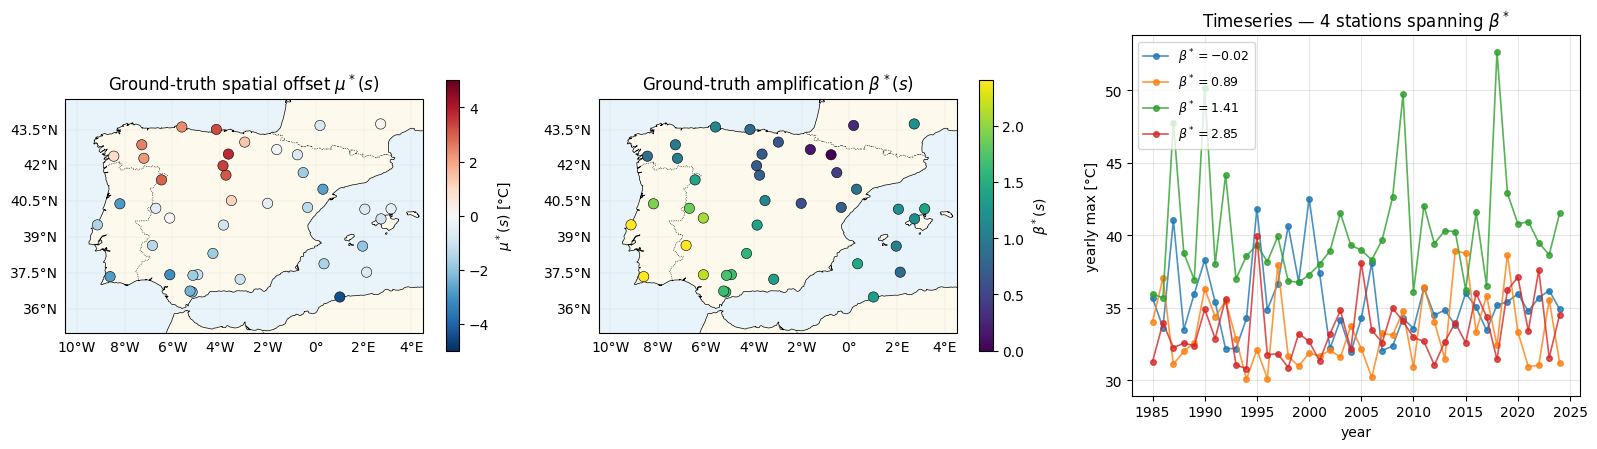

In [6]:
def plot_stations(ax, values, *, cmap: str, vlim: tuple, label: str) -> None:
    ax.set_extent([SPAIN_BBOX[0] - 1, SPAIN_BBOX[1] + 1, SPAIN_BBOX[2] - 1, SPAIN_BBOX[3] + 1], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)
    ax.add_feature(cfeature.OCEAN, facecolor="#e8f3fa")
    ax.add_feature(cfeature.LAND, facecolor="#fdf9ec")
    sc = ax.scatter(
        np.asarray(lon_st), np.asarray(lat_st), c=np.asarray(values), cmap=cmap,
        vmin=vlim[0], vmax=vlim[1], s=55, edgecolors="k", linewidths=0.4,
        transform=ccrs.PlateCarree(), zorder=5,
    )
    gl = ax.gridlines(draw_labels=True, linewidth=0.2, alpha=0.4)
    gl.top_labels = gl.right_labels = False
    plt.colorbar(sc, ax=ax, shrink=0.75, label=label)


fig = plt.figure(figsize=(16, 4.6))
ax_mu = fig.add_subplot(1, 3, 1, projection=ccrs.PlateCarree())
plot_stations(ax_mu, mu_truth, cmap="RdBu_r", vlim=(-5, 5), label=r"$\mu^*(s)$ [°C]")
ax_mu.set_title(r"Ground-truth spatial offset $\mu^*(s)$")
ax_beta = fig.add_subplot(1, 3, 2, projection=ccrs.PlateCarree())
plot_stations(ax_beta, beta_truth, cmap="viridis", vlim=(0.0, 2.4), label=r"$\beta^*(s)$")
ax_beta.set_title(r"Ground-truth amplification $\beta^*(s)$")
order_beta = jnp.argsort(beta_truth)
picks = jnp.array([order_beta[0], order_beta[S // 3], order_beta[2 * S // 3], order_beta[-1]])
ax_ts = fig.add_subplot(1, 3, 3)
for s in picks:
    s_i = int(s)
    ax_ts.plot(YEARS, y_obs[s_i, :], "o-", lw=1.2, ms=4, alpha=0.8, label=rf"$\beta^*={float(beta_truth[s_i]):.2f}$")
ax_ts.set_xlabel("year")
ax_ts.set_ylabel("yearly max [°C]")
ax_ts.set_title(r"Timeseries — 4 stations spanning $\beta^*$")
ax_ts.legend(loc="upper left", fontsize=9)
ax_ts.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## The multiplicative prior covariance as a `gaussx.SumKronecker`

Purely pedagogical: assemble the full-grid prior covariance with `gaussx`
operators (kernels from `pyrox.matern_kernel`) and inspect its storage cost.
We never materialise it during training.

In [7]:
K_s0 = matern_kernel(stations, stations, jnp.asarray(2.0), jnp.asarray(2.0), nu=1.5)
K_beta0 = matern_kernel(stations, stations, jnp.asarray(0.2), jnp.asarray(3.0), nu=1.5)
J_t = jnp.ones((T, T))
dd_t = jnp.outer(d_vec, d_vec)

K_mu_full = gaussx.Kronecker(
    lx.MatrixLinearOperator(K_s0, lx.positive_semidefinite_tag),
    lx.MatrixLinearOperator(J_t, lx.positive_semidefinite_tag),
)
K_beta_full = gaussx.Kronecker(
    lx.MatrixLinearOperator(K_beta0, lx.positive_semidefinite_tag),
    lx.MatrixLinearOperator(dd_t, lx.positive_semidefinite_tag),
)
K_tau = gaussx.SumKronecker(K_mu_full, K_beta_full)
print(f"prior operator:   {type(K_tau).__name__}")
print(f"  logical shape:  ({K_tau.in_size()}, {K_tau.in_size()})  = ({S}·{T}, {S}·{T})")
print(f"  storage cost:   {2 * (S * S + T * T)} entries (vs {(S * T) ** 2} dense, "
      f"{(S * T) ** 2 / (2 * (S * S + T * T)):.0f}× compression)")
print("  time-rank:      1 + 1 = 2  (J_T and dd^T each rank 1)")

prior operator:   SumKronecker
  logical shape:  (1600, 1600)  = (40·40, 40·40)
  storage cost:   6400 entries (vs 2560000 dense, 400× compression)
  time-rank:      1 + 1 = 2  (J_T and dd^T each rank 1)


## The model — two spatial GPs + xtremax GEV likelihood

A NumPyro program with two `pyrox` spatial GPs ($\mu(s)$ and $\tilde\beta(s)$,
distinct `pyrox_name`s so their hyperprior sites don't collide), both centered,
a trainable intercept $\beta_0$, and an `xtremax` GEV likelihood. SVI with an
`AutoNormal` guide replaces nb 01's hand-rolled scaffold.

In [8]:
def model(stations, d_vec, y=None):
    k_mu = Matern(pyrox_name="k_mu", nu=1.5)
    k_mu.set_prior("variance", dist.LogNormal(jnp.log(2.0), 0.5))
    k_mu.set_prior("lengthscale", dist.LogNormal(jnp.log(2.0), 0.5))
    k_beta = Matern(pyrox_name="k_beta", nu=1.5)
    k_beta.set_prior("variance", dist.LogNormal(jnp.log(0.2), 0.5))
    k_beta.set_prior("lengthscale", dist.LogNormal(jnp.log(3.0), 0.5))

    mu_s = gp_sample("mu_s", GPPrior(kernel=k_mu, X=stations), whitened=True)
    beta_tilde = gp_sample("beta_tilde", GPPrior(kernel=k_beta, X=stations), whitened=True)
    mu_s = mu_s - jnp.mean(mu_s)            # level -> mu0
    beta_tilde = beta_tilde - jnp.mean(beta_tilde)  # mean rate -> beta0

    mu0 = numpyro.sample("mu0", dist.Normal(Y_MEAN, 5.0))
    beta0 = numpyro.sample("beta0", dist.Normal(1.0, 0.5))
    log_sigma = numpyro.sample("log_sigma", dist.Normal(jnp.log(2.0), 0.4))
    xi = numpyro.sample("xi", dist.Normal(0.1, 0.1))
    sigma = jnp.exp(log_sigma)

    beta_s = beta0 + beta_tilde
    loc = mu0 + mu_s[:, None] + beta_s[:, None] * d_vec[None, :]

    numpyro.deterministic("mu_field", mu_s)
    numpyro.deterministic("beta_field", beta_s)
    numpyro.deterministic("sigma", sigma)
    numpyro.sample("y", GEV(loc=loc, scale=sigma, concentration=xi), obs=y)

## Inference — SVI

In [9]:
guide = autoguide.AutoNormal(
    model,
    init_loc_fn=init_to_value(
        values={"mu0": Y_MEAN, "beta0": 1.0, "log_sigma": float(jnp.log(2.0)), "xi": 0.1}
    ),
)
optimizer = numpyro.optim.optax_to_numpyro(
    optax.chain(optax.zero_nans(), optax.clip_by_global_norm(10.0), optax.adam(3e-3))
)
svi = SVI(model, guide, optimizer, Trace_ELBO())

t0 = time.time()
svi_result = svi.run(jr.PRNGKey(0), 6000, stations, d_vec, y_obs, progress_bar=False)
losses = np.asarray(svi_result.losses)
post = Predictive(model, guide=guide, params=svi_result.params, num_samples=600)(
    jr.PRNGKey(3), stations, d_vec
)
lat = guide.sample_posterior(jr.PRNGKey(4), svi_result.params, sample_shape=(600,))
print(f"SVI finished in {time.time() - t0:.1f}s")

beta_field = post["beta_field"]
print(f"fitted μ₀    = {float(lat['mu0'].mean()):.2f}  (truth {TRUTH['mu0']})")
print(f"fitted β₀    = {float(lat['beta0'].mean()):.2f}  (truth mean β* {float(beta_truth.mean()):.2f})")
print(f"fitted β(s)  range [{float(beta_field.mean(0).min()):.2f}, {float(beta_field.mean(0).max()):.2f}]  "
      f"(truth [{float(beta_truth.min()):.2f}, {float(beta_truth.max()):.2f}])")
print(f"fitted σ     = {float(post['sigma'].mean()):.2f}  (truth {TRUTH['gev_sigma']})")
print(f"fitted ξ     = {float(lat['xi'].mean()):.3f}  (truth {TRUTH['gev_xi']})")

SVI finished in 16.2s
fitted μ₀    = 34.66  (truth 35.0)
fitted β₀    = 1.34  (truth mean β* 1.23)
fitted β(s)  range [0.87, 1.68]  (truth [-0.02, 2.85])
fitted σ     = 1.77  (truth 1.8)
fitted ξ     = 0.131  (truth 0.12)


### Loss curve

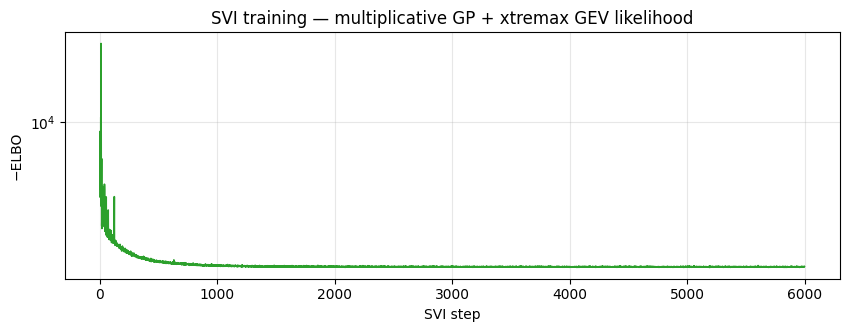

In [10]:
fig, ax = plt.subplots(figsize=(10, 3.2))
finite = np.isfinite(losses)
ax.plot(np.arange(len(losses))[finite], losses[finite], "C2-", lw=1.2)
ax.set_xlabel("SVI step")
ax.set_ylabel("−ELBO")
ax.set_yscale("symlog", linthresh=100.0)
ax.set_title("SVI training — multiplicative GP + xtremax GEV likelihood")
ax.grid(alpha=0.3, which="both")
plt.show()

## Parameter recovery

The headline is the $\beta(s)$ map: recovering a smoothly-varying warming rate
from 40 stations × 40 years of GEV maxima. The GP prior shrinks the posterior
amplitude toward $\beta_0$, but the **spatial pattern** is recovered.

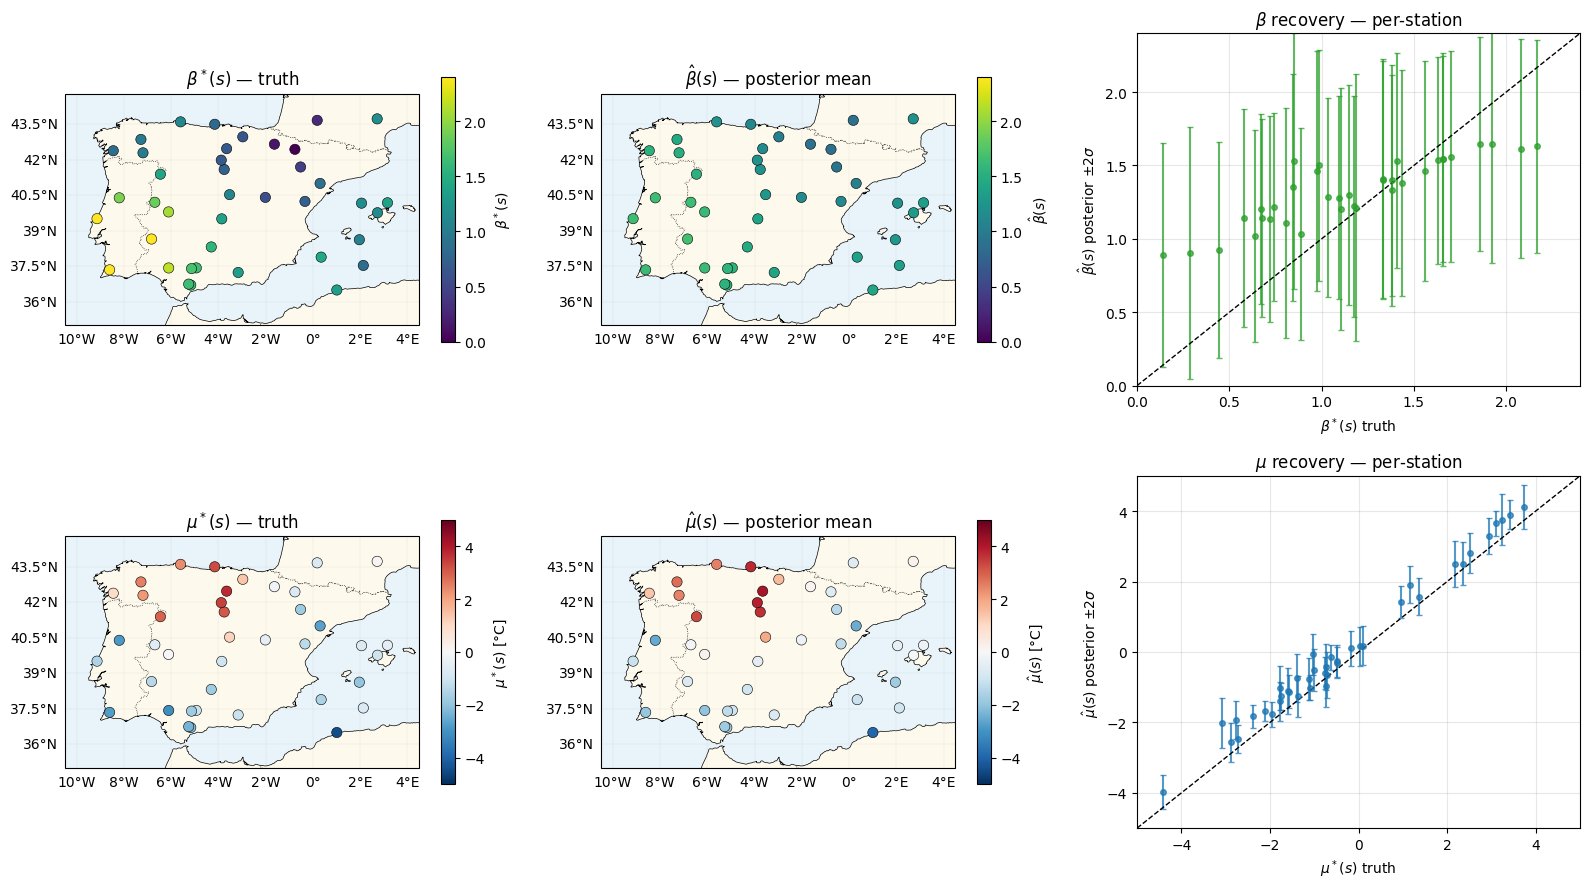

In [11]:
beta_mean = beta_field.mean(0)
beta_std = beta_field.std(0)
mu_mean = post["mu_field"].mean(0)
mu_std = post["mu_field"].std(0)
vlim_beta, vlim_mu = (0.0, 2.4), (-5.0, 5.0)

fig = plt.figure(figsize=(16, 9))
ax = fig.add_subplot(2, 3, 1, projection=ccrs.PlateCarree())
plot_stations(ax, beta_truth, cmap="viridis", vlim=vlim_beta, label=r"$\beta^*(s)$")
ax.set_title(r"$\beta^*(s)$ — truth")
ax = fig.add_subplot(2, 3, 2, projection=ccrs.PlateCarree())
plot_stations(ax, beta_mean, cmap="viridis", vlim=vlim_beta, label=r"$\hat\beta(s)$")
ax.set_title(r"$\hat\beta(s)$ — posterior mean")
ax = fig.add_subplot(2, 3, 3)
ax.errorbar(np.asarray(beta_truth), np.asarray(beta_mean), yerr=2 * np.asarray(beta_std),
            fmt="o", color="C2", ms=4, alpha=0.75, capsize=2)
ax.plot(vlim_beta, vlim_beta, "k--", lw=1)
ax.set_xlim(*vlim_beta)
ax.set_ylim(*vlim_beta)
ax.set_xlabel(r"$\beta^*(s)$ truth")
ax.set_ylabel(r"$\hat\beta(s)$ posterior $\pm 2\sigma$")
ax.set_title(r"$\beta$ recovery — per-station")
ax.grid(alpha=0.3)
ax = fig.add_subplot(2, 3, 4, projection=ccrs.PlateCarree())
plot_stations(ax, mu_truth, cmap="RdBu_r", vlim=vlim_mu, label=r"$\mu^*(s)$ [°C]")
ax.set_title(r"$\mu^*(s)$ — truth")
ax = fig.add_subplot(2, 3, 5, projection=ccrs.PlateCarree())
plot_stations(ax, mu_mean, cmap="RdBu_r", vlim=vlim_mu, label=r"$\hat\mu(s)$ [°C]")
ax.set_title(r"$\hat\mu(s)$ — posterior mean")
ax = fig.add_subplot(2, 3, 6)
ax.errorbar(np.asarray(mu_truth), np.asarray(mu_mean), yerr=2 * np.asarray(mu_std),
            fmt="o", color="C0", ms=4, alpha=0.75, capsize=2)
ax.plot(vlim_mu, vlim_mu, "k--", lw=1)
ax.set_xlim(*vlim_mu)
ax.set_ylim(*vlim_mu)
ax.set_xlabel(r"$\mu^*(s)$ truth")
ax.set_ylabel(r"$\hat\mu(s)$ posterior $\pm 2\sigma$")
ax.set_title(r"$\mu$ recovery — per-station")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### GEV tail recovery

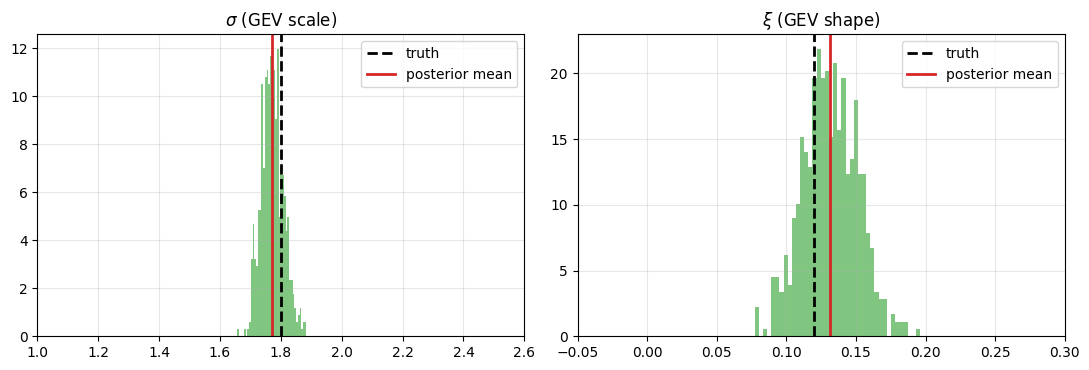

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, (name, truth_val, draws, xr) in zip(
    axes,
    [(r"$\sigma$ (GEV scale)", TRUTH["gev_sigma"], post["sigma"], (1.0, 2.6)),
     (r"$\xi$ (GEV shape)", TRUTH["gev_xi"], lat["xi"], (-0.05, 0.3))],
    strict=True,
):
    ax.hist(np.asarray(draws).ravel(), bins=40, color="C2", alpha=0.6, density=True)
    ax.axvline(truth_val, color="k", ls="--", lw=2, label="truth")
    ax.axvline(float(np.mean(draws)), color="C3", lw=2, label="posterior mean")
    ax.set_xlim(*xr)
    ax.set_title(name)
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Return-level maps — now spatially varying

$\hat\tau(s, t^*) = \mu_0 + \hat\mu(s) + \hat\beta(s)\,d(t^*)$, then
$z_p(s) = $ `gev_return_level`. Because $\hat\beta(s)$ is location-dependent,
the 2024 → 2050 warming shift is **non-uniform** — the key difference from nb 01.

100-yr return shift 2024→2050:  mean 0.74 °C,  range [0.48, 0.93] °C
  (spatial spread is the new feature; nb 01 had zero spread here)


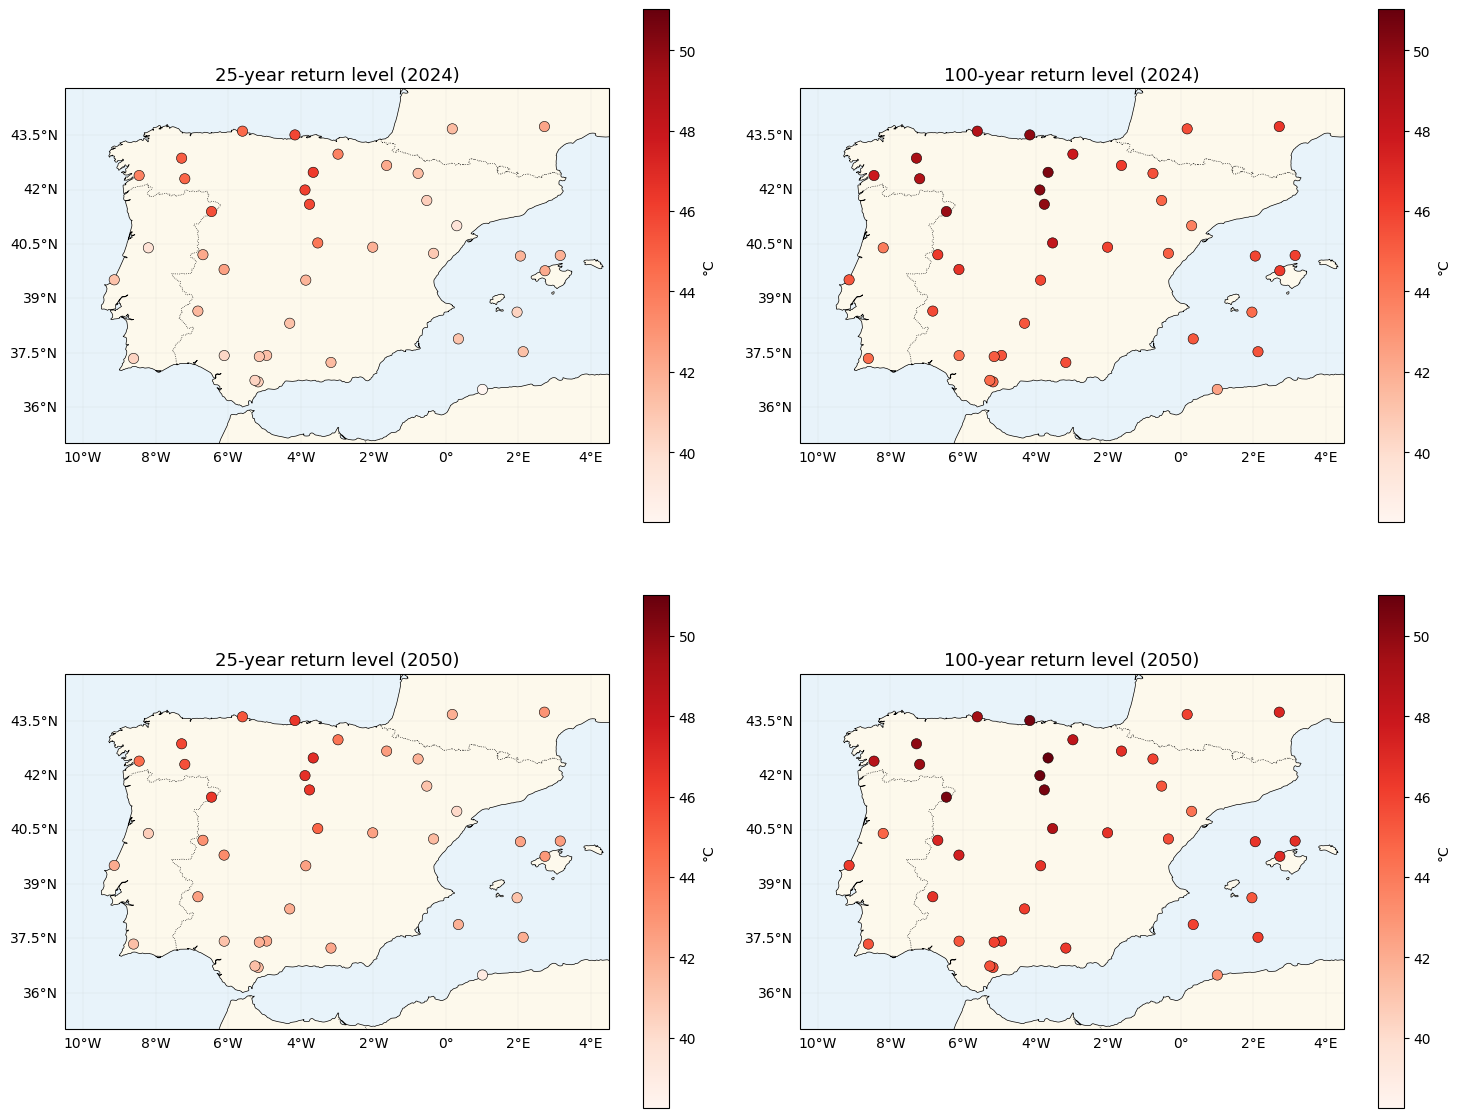

In [13]:
mu0_p = float(lat["mu0"].mean())
beta_field_mean = beta_field.mean(0)
mu_field_mean = post["mu_field"].mean(0)
sigma_p = float(post["sigma"].mean())
xi_p = float(lat["xi"].mean())

gmst_2024 = gmst[-1]
gmst_2050 = gmst[-1] + (gmst[-1] - gmst[0]) / (T - 1) * (2050 - (YEAR_0 + T - 1))
tau_2024 = mu0_p + mu_field_mean + beta_field_mean * (gmst_2024 - jnp.mean(gmst))
tau_2050 = mu0_p + mu_field_mean + beta_field_mean * (gmst_2050 - jnp.mean(gmst))

z25_2024 = gev_return_level(25.0, tau_2024, sigma_p, xi_p)
z100_2024 = gev_return_level(100.0, tau_2024, sigma_p, xi_p)
z25_2050 = gev_return_level(25.0, tau_2050, sigma_p, xi_p)
z100_2050 = gev_return_level(100.0, tau_2050, sigma_p, xi_p)
shift_100 = z100_2050 - z100_2024

stacked = jnp.stack([z25_2024, z100_2024, z25_2050, z100_2050])
vmin, vmax = float(jnp.min(stacked)), float(jnp.max(stacked))
print(f"100-yr return shift 2024→2050:  mean {float(jnp.mean(shift_100)):.2f} °C,  "
      f"range [{float(shift_100.min()):.2f}, {float(shift_100.max()):.2f}] °C")
print("  (spatial spread is the new feature; nb 01 had zero spread here)")

fig, axes = plt.subplots(2, 2, figsize=(15, 13), subplot_kw={"projection": ccrs.PlateCarree()})
for ax, values, title in zip(
    axes.flat, [z25_2024, z100_2024, z25_2050, z100_2050],
    ["25-year return level (2024)", "100-year return level (2024)",
     "25-year return level (2050)", "100-year return level (2050)"],
    strict=True,
):
    plot_stations(ax, values, cmap="Reds", vlim=(vmin, vmax), label="°C")
    ax.set_title(title, fontsize=13)
plt.tight_layout()
plt.show()

### The spatial pattern of warming

$z_{100}(2050) - z_{100}(2024)$ directly. Under nb 01 this map would be
constant; here it tracks $\hat\beta(s)$.

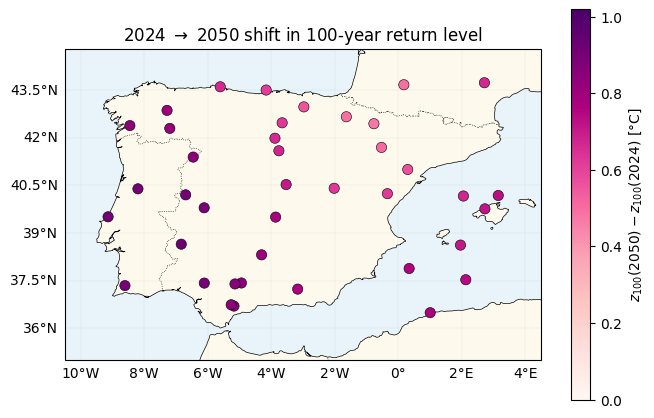

In [14]:
shift_abs = float(jnp.max(jnp.abs(shift_100)))
fig, ax = plt.subplots(figsize=(6.8, 5.5), subplot_kw={"projection": ccrs.PlateCarree()})
plot_stations(ax, shift_100, cmap="RdPu", vlim=(0.0, 1.1 * shift_abs),
              label=r"$z_{100}(2050) - z_{100}(2024)$ [°C]")
ax.set_title(r"2024 $\to$ 2050 shift in 100-year return level")
plt.tight_layout()
plt.show()

## Contrast with the additive model (nb 01)

| Aspect | Additive (nb 01) | Multiplicative (this nb) |
|---|---|---|
| Temporal structure | $\beta\,d(t) + \tau_r(t)$, one $\beta$ | $\beta(s)\,d(t)$, per-station rate |
| Prior covariance | $K_\mu \otimes I_T + I_S \otimes K_t$ | $K_\mu \otimes J_T + K_\beta \otimes dd^\top$ |
| Time rank | full ($T$) | 2 |
| Latent fields | $\mu(s)$, $\tau_r(t)$ | $\mu(s)$, $\tilde\beta(s)$ |
| 2050 warming map | constant | spatially varying |

Both share the same machinery — `pyrox` GP latents, `xtremax` GEV likelihood,
NumPyro SVI — with only $\tau(s,t)$'s definition and the second GP changing.

## Summary

- The multiplicative model's prior is `gaussx.SumKronecker` of two rank-1
  Kronecker products; time-rank 2 because $d(t)$ is a known covariate.
- Inference reuses the nb 01 stack verbatim: two `pyrox` spatial GPs via
  whitened `gp_sample`, an `xtremax` GEV likelihood, NumPyro SVI; centering
  both fields fixes the $\mu_0 / \mu(s)$ and $\beta_0 / \tilde\beta(s)$
  identifiabilities.
- The payoff is a **spatially heterogeneous warming signal**: high-$\beta$
  regions warm faster, so the 100-year return-level shift is a map, not a
  constant.

### Follow-ups

- **Non-stationary GEV** — let $\sigma$, $\xi$ vary across space via their own
  spatial GPs (nb 03).
- **Higher-rank coregionalisation** — a 3–4 component temporal basis with $\beta$
  a matrix of location weights.